# Black-Scholes Finite Difference Solver

This notebook prices European and American options by solving the Black-Scholes PDE numerically using finite difference methods.

### Methods
- **Backward Euler** — first order in time, unconditionally stable
- **Crank-Nicolson** — second order in time, unconditionally stable
- **Rannacher smoothing** — CN with two initial backward Euler half-steps to remove oscillations near the strike
- **PSOR** — projected SOR iteration for American options (enforces early exercise constraint)

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt
from option_fd import (
    thomas_solver,
    price_euro_call_be, price_euro_call_cn, price_euro_call_cn_rannacher,
    price_euro_put_be,  price_euro_put_cn,  price_euro_put_cn_rannacher,
    price_american_put_psor_be, price_american_put_psor_cn
)

# Market parameters
S_0   = 100.0
K     = 100.0
sigma = 0.2
r     = 0.05
T     = 1.0

# Grid parameters
S_max = 400.0
M     = 1000
N     = 1000

## 2. Black-Scholes PDE and Backward Euler Discretization

Given parameters $\sigma$ (volatility), $r$ (risk free rate), $K$ (strike price), the PDE is:
<br>
$\frac{\partial V}{\partial t} +\frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2} +rS \frac{\partial V}{\partial S} -rV=0$
<br>
We assume the value of the option $V:[0,S_{max}]\times [0,T] \to \mathbb{R}$, where $T$ is the time length of the contract and $S_{max}$ is a chosen cutoff for the maximum price of our stock. We also impose the boundary conditions for a call:
<br>
$V(0,t)=0$
<br>
$V(S,T)=\max (S-K,0)$
<br>
$V(S_{max},t)=S_{max}-Ke^{-r(T-t)}$
<br><br>
Next, we divide the domain $[0,S_{max}]\times [0,T]$.
<br>
Put $t_n=\frac{n}{N}T$ for $n=1,...,N$, where $\Delta t=\frac{T}{N}$
<br>
Put $s_i=\frac{i}{M}S_{max}$ for $i=1,...,M$, where $\Delta S=\frac{S_{max}}{M}$
<br><br>
We utilize the difference quotient formulas:
<br>
$\frac{\partial V}{\partial t}(s_i,t_n)=\frac{V(s_i,t_{n+1})-V(s_i,t_n)}{\Delta t}+ \mathcal{O}(\Delta t)$
<br>
$\frac{\partial V}{\partial S}(s_i,t_n)=\frac{V(s_{i+1},t_n)-V(s_{i-1},t_n)}{2\Delta S}+ \mathcal{O}((\Delta S)^2)$
<br>
$\frac{\partial^2 V}{\partial S^2}(s_i,t_n)=\frac{V(s_{i+1},t_n)-2V(s_i,t_n)+V(s_{i-1},t_n)}{(\Delta S)^2}+ \mathcal{O}((\Delta S)^2)$
<br><br>
Evaluating the PDE at $(s_i,t_n)$ and discretizing:
<br>
$\bigl(\frac{V(s_i,t_{n+1})-V(s_i,t_n)}{\Delta t}\bigr) +\frac{1}{2}\sigma^2{s_i}^2\bigl(\frac{V(s_{i+1},t_n)-2V(s_i,t_n)+V(s_{i-1},t_n)}{(\Delta S)^2} \bigr) +rs_i\bigl(\frac{V(s_{i+1},t_n)-V(s_{i-1},t_n)}{2\Delta S}\bigr) -rV(s_i,t_n)=0$
<br><br>
Rearranging gives $a_iV(s_{i-1},t_n) +b_i V(s_{i},t_n) +c_i V(s_{i+1},t_n)=V(s_i,t_{n+1})$, where:
<br><br>
$a_i=\frac{rs_i\Delta t}{2\Delta S} -\frac{1}{2}\sigma^2 {s_i}^2 \frac{\Delta t}{(\Delta S)^2}$
<br><br>
$b_i=1+\sigma^2{s_i}^2\frac{\Delta t}{(\Delta S)^2} +r\Delta t$
<br><br>
$c_i=-\frac{1}{2}\sigma^2 {s_i}^2\frac{ \Delta t}{(\Delta S)^2} - \frac{rs_i\Delta t}{2\Delta S}$
<br><br>
**Boundary treatment.** For $i=M-1$, using $V(s_M,t_n)=S_{max}-Ke^{-r(T-t_n)}$:
<br><br>
$a_{M-1}V(s_{M-2},t_n) +b_{M-1} V(s_{M-1},t_n) =V(s_{M-1},t_{n+1})-c_{M-1} \bigl(S_{max}-Ke^{-r(T-t_n)}\bigr)$
<br><br>
For $i=1$, using $V(0,t)=0$:
<br><br>
$b_1 V(s_{1},t_n) +c_1 V(s_{2},t_n)=V(s_1,t_{n+1})$
<br><br>
This gives a tridiagonal system solved at each time step by the Thomas algorithm:
$$A = \begin{pmatrix} b_1 & c_1 & 0 & \cdots & 0 \\ a_2 & b_2 & c_2 & \ddots & \vdots \\ 0 & a_3 & b_3 & \ddots & 0 \\ \vdots & \ddots & \ddots & \ddots & c_{M-2} \\ 0 & \cdots & 0 & a_{M-1} & b_{M-1} \end{pmatrix}$$

## 3. Crank-Nicolson

Define the spatial operator $LV=\frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2} +rS \frac{\partial V}{\partial S} -rV$, so the PDE is $\frac{\partial V}{\partial t}=-LV$.
<br><br>
Instead of evaluating the spatial operator at $t_n$ only, we average over $t_n$ and $t_{n+1}$:
<br><br>
$\bigl(\frac{V(s_i,t_{n+1})-V(s_i,t_n)}{\Delta t}\bigr)=-\frac{1}{2}\bigl( LV(s_i,t_n) +LV(s_i,t_{n+1})\bigr)$
<br><br>
Rearranging: $\bigl(I+\frac{\Delta t}{2}L\bigr)V(s_i,t_{n+1})=\bigl(I-\frac{\Delta t}{2}L\bigr)V(s_i,t_{n})$
<br><br>
Expanding and discretizing:
<br><br>
$A^{-}_{i}V(s_{i-1},t_{n})+A^{0}_{i}V(s_{i},t_{n})+A^+_{i}V(s_{i+1},t_{n})=B^{-}_{i}V(s_{i-1},t_{n+1})+B^{0}_iV(s_{i},t_{n+1})+B^+_iV(s_{i+1},t_{n+1})$
<br><br>
where
<br>
$A^{-}_{i}=\bigl[-\frac{\Delta t}{2}\bigl(\frac{1}{2}\sigma^2s_i^2\frac{1}{(\Delta S)^2}-rs_i\frac{1}{2\Delta S}\bigr)\bigr]$
<br>
$A^{0}_{i}=\bigl[1-\frac{\Delta t}{2}\bigl(-\sigma^2s_i^2\frac{1}{(\Delta S)^2}-r\bigr)\bigr]$
<br>
$A^{+}_{i}=\bigl[-\frac{\Delta t}{2}\bigl(\frac{1}{2}\sigma^2s_i^2\frac{1}{(\Delta S)^2}+rs_i\frac{1}{2\Delta S}\bigr)\bigr]$
<br>
$B^{-}_{i}=\bigl[\frac{\Delta t}{2}\bigl(\frac{1}{2}\sigma^2s_i^2\frac{1}{(\Delta S)^2}-rs_i\frac{1}{2\Delta S}\bigr)\bigr]$
<br>
$B^{0}_{i}=\bigl[1+\frac{\Delta t}{2}\bigl(-\sigma^2s_i^2\frac{1}{(\Delta S)^2}-r\bigr)\bigr]$
<br>
$B^{+}_{i}=\bigl[\frac{\Delta t}{2}\bigl(\frac{1}{2}\sigma^2s_i^2\frac{1}{(\Delta S)^2}+rs_i\frac{1}{2\Delta S}\bigr)\bigr]$
<br><br>
**Boundary treatment for $i=M-1$:**
<br><br>
$A^{-}_{M-1}V(s_{M-2},t_{n})+A^{0}_{M-1}V(s_{M-1},t_{n})=B^{-}_{M-1}V(s_{M-2},t_{n+1})+B^0_{M-1}V(s_{M-1},t_{n+1})+B^+_{M-1}\bigl(S_{max}-Ke^{-r(T-t_{n+1})}\bigr)-A^+_{M-1}\bigl(S_{max}-Ke^{-r(T-t_{n})}\bigr)$
<br><br>
For $i=1$:
<br><br>
$A^{0}_{1}V(s_{1},t_{n})+A^+_{1}V(s_{2},t_{n})=B^{0}_1V(s_{1},t_{n+1})+B^+_1V(s_{2},t_{n+1})$
<br><br>
At $n=N-1$ the terminal condition enters the RHS:
<br><br>
$A^{-}_{i}V(s_{i-1},t_{N-1})+A^{0}_{i}V(s_{i},t_{N-1})+A^+_{i}V(s_{i+1},t_{N-1})=B^{-}_{i}\max(s_{i-1}-K,0)+B^{0}_i\max(s_{i}-K,0)+B^+_i\max(s_{i+1}-K,0)$
<br><br>
**Rannacher smoothing**: the non-smooth payoff causes spurious CN oscillations near the strike. Two backward Euler half-steps at $t=T$ suppress these before switching to CN.

## 4. Black-Scholes Closed Form

$C(S_0,0)=S_0 \Phi(d_1)-Ke^{-rT}\Phi(d_2)$
<br><br>
where $d_1=\frac{\ln(\frac{S_0}{K})+(r+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$, $\quad d_2=d_1-\sigma\sqrt{T}$, $\quad$ and $\Phi$ is the standard normal CDF.

In [2]:
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_call_closed_form(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm_cdf(d1) - K*np.exp(-r*T)*norm_cdf(d2)

def bs_put_closed_form(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm_cdf(-d2) - S*norm_cdf(-d1)

exact_call = bs_call_closed_form(S_0, K, r, sigma, T)
exact_put  = bs_put_closed_form(S_0, K, r, sigma, T)
print(f"BS call: {exact_call:.6f}")
print(f"BS put:  {exact_put:.6f}")

BS call: 10.450584
BS put:  5.573526


## 5. European Options: FD vs Closed Form

In [3]:
_, _, be_call = price_euro_call_be(S_0, K, sigma, r, T, S_max, M, N)
_, _, cn_call = price_euro_call_cn(S_0, K, sigma, r, T, S_max, M, N)
_, _, ra_call = price_euro_call_cn_rannacher(S_0, K, sigma, r, T, S_max, M, N)

_, _, be_put  = price_euro_put_be(S_0, K, sigma, r, T, S_max, M, N)
_, _, cn_put  = price_euro_put_cn(S_0, K, sigma, r, T, S_max, M, N)
_, _, ra_put  = price_euro_put_cn_rannacher(S_0, K, sigma, r, T, S_max, M, N)

print(f"{'Method':<25} {'Call Price':>12} {'Call Error':>12} {'Put Price':>12} {'Put Error':>12}")
print("-" * 75)
for name, cp, pp in [
    ("Black-Scholes (exact)", exact_call, exact_put),
    ("Backward Euler",        be_call,    be_put),
    ("Crank-Nicolson",        cn_call,    cn_put),
    ("CN + Rannacher",        ra_call,    ra_put),
]:
    ce = abs(cp - exact_call) if name != "Black-Scholes (exact)" else 0
    pe = abs(pp - exact_put)  if name != "Black-Scholes (exact)" else 0
    print(f"{name:<25} {cp:>12.6f} {ce:>12.6f} {pp:>12.6f} {pe:>12.6f}")

Method                      Call Price   Call Error    Put Price    Put Error
---------------------------------------------------------------------------
Black-Scholes (exact)        10.450584     0.000000     5.573526     0.000000
Backward Euler               10.449139     0.001445     5.572200     0.001326
Crank-Nicolson               10.450189     0.000395     5.573131     0.000395
CN + Rannacher               10.450188     0.000396     5.573131     0.000395


## 6. Convergence Study

To isolate temporal and spatial error we run two separate studies:
- **Time convergence**: fix $M$ large (so spatial error is negligible), refine $N$. Expected: $O(\Delta t)$ for BE, $O(\Delta t^2)$ for CN.
- **Space convergence**: fix $N$ large (so temporal error is negligible), refine $M$. Expected: $O(\Delta S^2)$ for both, since central differences are used in space.

Empirical order is computed as $p = \log_2(e_N / e_{2N})$.

In [4]:
exact = bs_call_closed_form(S_0, K, r, sigma, T)

# --- Time convergence: fix M large, refine N ---
print("TIME CONVERGENCE — fixed M=2000")
print(f"{'N':>6} {'dt':>10} {'BE error':>12} {'BE order':>10} {'CN error':>12} {'CN order':>10}")
prev_be, prev_cn = None, None
for N_ in [25, 50, 100, 200, 400]:
    _, _, p_be = price_euro_call_be(S_0, K, sigma, r, T, S_max, 2000, N_)
    _, _, p_cn = price_euro_call_cn_rannacher(S_0, K, sigma, r, T, S_max, 16000, N_)
    e_be = abs(p_be - exact)
    e_cn = abs(p_cn - exact)
    o_be = f"{np.log2(prev_be/e_be):.3f}" if prev_be else "—"
    o_cn = f"{np.log2(prev_cn/e_cn):.3f}" if prev_cn else "—"
    print(f"{N_:>6} {T/N_:>10.3e} {e_be:>12.3e} {o_be:>10} {e_cn:>12.3e} {o_cn:>10}")
    prev_be, prev_cn = e_be, e_cn

# --- Space convergence: fix N large, refine M ---
print("\nSPACE CONVERGENCE — fixed N=8000")
print(f"{'M':>6} {'dS':>10} {'BE error':>12} {'BE order':>10} {'CN error':>12} {'CN order':>10}")
prev_be, prev_cn = None, None
for M_ in [50, 100, 200, 400]:
    _, _, p_be = price_euro_call_be(S_0, K, sigma, r, T, S_max, M_, 8000)
    _, _, p_cn = price_euro_call_cn_rannacher(S_0, K, sigma, r, T, S_max, M_, 8000)
    e_be = abs(p_be - exact)
    e_cn = abs(p_cn - exact)
    o_be = f"{np.log2(prev_be/e_be):.3f}" if prev_be else "—"
    o_cn = f"{np.log2(prev_cn/e_cn):.3f}" if prev_cn else "—"
    print(f"{M_:>6} {S_max/M_:>10.3e} {e_be:>12.3e} {o_be:>10} {e_cn:>12.3e} {o_cn:>10}")
    prev_be, prev_cn = e_be, e_cn

TIME CONVERGENCE — fixed M=2000
     N         dt     BE error   BE order     CN error   CN order
    25  4.000e-02    4.197e-02          —    4.676e-04          —
    50  2.000e-02    2.106e-02      0.995    1.091e-04      2.100
   100  1.000e-02    1.059e-02      0.992    2.880e-05      1.921
   200  5.000e-03    5.343e-03      0.986    8.404e-06      1.777
   400  2.500e-03    2.722e-03      0.973    3.264e-06      1.364

SPACE CONVERGENCE — fixed N=8000
     M         dS     BE error   BE order     CN error   CN order
    50  8.000e+00    1.438e-01          —    1.439e-01          —
   100  4.000e+00    3.995e-02      1.848    3.982e-02      1.854
   200  2.000e+00    1.003e-02      1.994    9.898e-03      2.008
   400  1.000e+00    2.602e-03      1.946    2.471e-03      2.002


## 7. American Put via PSOR

For American puts, we can exercise at any time.
<br><br>
Boundary conditions:
<br>
$V(S,T)=\max (K-S,0)$
<br>
$V(S_{max},t)=0$
<br>
$V(0,t)=K$, since we have the option to exercise immediately and receive $K$.
<br><br>
Since we can exercise at any time, for $\Phi(S)=\max(K-S,0)$ we require:
<br><br>
$V(S,t)\geq \Phi(S)$ for all $t \in [0,T]$ and $S\in [0,S_{max}]$
<br><br>
**PSOR**: solving the tridiagonal system $a_iV_{i-1}+b_iV_i+c_iV_{i+1}=\text{rhs}_i$ for $V_i$ gives the Gauss-Seidel update:
<br><br>
$V^{(k+1)}(s_i,t_n)=\frac{1}{b_i}\Bigl(V(s_i,t_{n+1})- a_i\,V^{(k+1)}(s_{i-1},t_n)- c_i\,V^{(k)}(s_{i+1},t_n)\Bigr)$
<br><br>
Adding SOR relaxation with parameter $\omega \in (1,2)$ and projecting onto the constraint:
<br><br>
$V^{(k+1)}(s_i,t_n) = \max\!\Bigl((1-\omega)\,V^{(k)}(s_i,t_n) + \frac{\omega}{b_i}\Bigl(V(s_i,t_{n+1}) - a_i\,V^{(k+1)}(s_{i-1},t_n) - c_i\,V^{(k)}(s_{i+1},t_n)\Bigr),\,\Phi(s_i)\Bigr)$
<br><br>
Iterate until $\|V^{(k+1)} - V^{(k)}\|_\infty < \text{tol}$.

European put (CN):       5.573131
American put (PSOR-CN):  6.089891
Early exercise premium:  0.516760


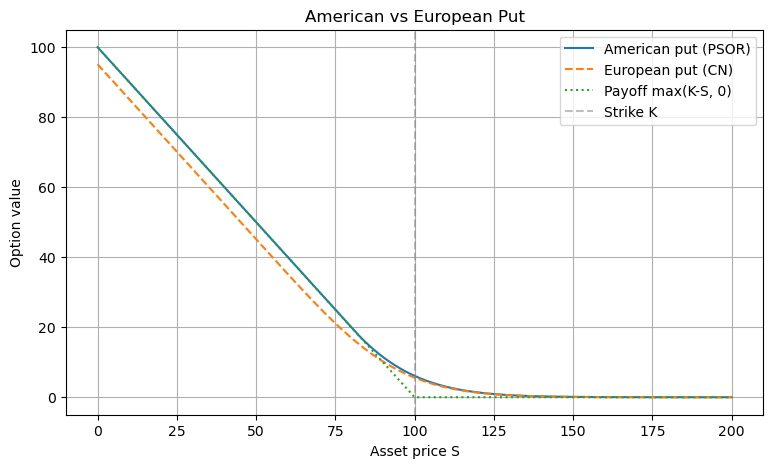

In [5]:
S_amer, V_amer, amer_price = price_american_put_psor_cn(S_0, K, sigma, r, T, S_max, M, N)
_, V_euro, euro_price      = price_euro_put_cn(S_0, K, sigma, r, T, S_max, M, N)

print(f"European put (CN):       {euro_price:.6f}")
print(f"American put (PSOR-CN):  {amer_price:.6f}")
print(f"Early exercise premium:  {amer_price - euro_price:.6f}")

payoff = np.maximum(K - S_amer, 0.0)
mask   = S_amer <= 2*K

plt.figure(figsize=(9, 5))
plt.plot(S_amer[mask], V_amer[mask], label='American put (PSOR)')
plt.plot(S_amer[mask], V_euro[mask], label='European put (CN)', linestyle='--')
plt.plot(S_amer[mask], payoff[mask], label='Payoff max(K-S, 0)', linestyle=':')
plt.axvline(K, color='gray', linestyle='--', alpha=0.5, label='Strike K')
plt.xlabel('Asset price S')
plt.ylabel('Option value')
plt.title('American vs European Put')
plt.legend(); plt.grid(True)
plt.savefig('american_put.png', dpi=150)
plt.show()